# Profession Gender Expertise Features

Fixed expertise features are discovered once, then tested on matched doctor and engineer prompts across control, male, and female variants.

## 1. Setup

One model, one SAE source, one fixed expertise feature list.

In [17]:
from __future__ import annotations

import json
import os
import re
from pathlib import Path
from dotenv import load_dotenv

import pandas as pd
import requests
from IPython.display import display

load_dotenv()

MODEL_ID = "gemma-2-2b"
SOURCE_SET = "gemmascope-res-16k"
EXPERTISE_TOP_K = 50
EXPERTISE_FEATURE_LIMIT = 20
ACTIVATION_THRESHOLD = 0.0

# Use "web" for https://www.neuronpedia.org/api/activation/new.
# Use "local" for a local Neuronpedia inference server at http://127.0.0.1:5002/v1.
ACTIVATION_BACKEND = os.environ.get("NEURONPEDIA_ACTIVATION_BACKEND", "web").lower()

if Path.cwd().name == "profession_concept_overlap":
    BASE_DIR = Path.cwd()
else:
    BASE_DIR = Path("profession_concept_overlap")

DATA_ROOT = BASE_DIR / "data" / f"{MODEL_ID}_{SOURCE_SET}"
EXPERTISE_SEARCH_DIR = DATA_ROOT / f"expertise_top{EXPERTISE_TOP_K}_content_sorted"
DETAIL_DIR = DATA_ROOT / "feature_details"
ACTIVATION_DIR = DATA_ROOT / f"fixed_expertise_top{EXPERTISE_FEATURE_LIMIT}_{ACTIVATION_BACKEND}_activations"
OUTPUT_DIR = BASE_DIR / "outputs"

for path in [EXPERTISE_SEARCH_DIR, DETAIL_DIR, ACTIVATION_DIR, OUTPUT_DIR]:
    path.mkdir(parents=True, exist_ok=True)

API_KEY = os.environ.get("NEURONPEDIA_API_KEY", "")
WEB_HEADERS = {"Content-Type": "application/json"}
if API_KEY:
    WEB_HEADERS["X-Api-Key"] = API_KEY
else:
    print("WARNING: NEURONPEDIA API key not found")

LOCAL_INFERENCE_BASE_URL = os.environ.get(
    "NEURONPEDIA_INFERENCE_BASE_URL",
    "http://127.0.0.1:5002/v1",
).rstrip("/")
LOCAL_INFERENCE_SECRET = os.environ.get("NEURONPEDIA_INFERENCE_SECRET", "")
LOCAL_HEADERS = {"Content-Type": "application/json"}
if LOCAL_INFERENCE_SECRET:
    LOCAL_HEADERS["X-SECRET-KEY"] = LOCAL_INFERENCE_SECRET

pd.set_option("display.max_colwidth", 180)
pd.set_option("display.max_rows", 100)

## 2. Prompts

Expertise prompts define the feature list. Profession prompts are only inference targets.

In [18]:
LANGUAGES = ["en", "fr"]
CURRENT_LANGUAGE = "en"

PROFESSION_STEMS = {
    "en": {
        "doctor": ["The doctor", "The male doctor", "The female doctor"],
        "engineer": ["The engineer", "The male engineer", "The female engineer"],
        "pilot": ["The pilot", "The male pilot", "The female pilot"],
        "teacher": ["The teacher", "The male teacher", "The female teacher"],
    },
    "fr": {
        # Note that médecin and pilote are gender-neutral professions so we have to specify 'homme' and 'femme'.
        # Engineer and teacher have gender-specific profession names so we can avoid homme and femme but have to choose a synonym for the role, hence spécialiste and professeur.
        # All of these control words are masculine nouns but are gender-neutral (notwithstanding cultural norms of 'professeur' and so forth).
        "médecin": ["Le médecin", "L'homme médecin", "La femme médecin"],
        "spécialiste": ["Le spécialiste", "L'ingénieur", "L'ingénieure"], #
        "pilote": ["Le pilote", "L'homme pilote", "La femme pilote"],
        "professeur": ["Le professeur", "L'enseignant", "L'enseignante"],
    }
}

ATTRIBUTES = {"en" :[
    (["competent"], "highly competent"),
    (["skilled"], "very skilled"),
    (["qualified", "expert"], "a qualified expert"),
    (["experienced", "capable"], "experienced and capable"),
], "fr":[
    (["compétent"], "très compétent"),
    (["qualifié"], "très qualifié"),
    (["qualifié", "expert"], "un expert qualifié"),
    (["expérimenté", "capable"], "expérimenté et capable"),
]}

TARGET_PROMPTS = []
for role, gendered_profession in PROFESSION_STEMS[CURRENT_LANGUAGE].items():
    for attr_words, text in ATTRIBUTES[CURRENT_LANGUAGE]:
        for idx, (ggroup, gender) in enumerate([('control', None), ('male', 'male'), ('female', 'female')]):
            TARGET_PROMPTS.append({
                "profession": role,
                "gender_group": ggroup,
                "gender": gender,
                "prompt": f"{gendered_profession[idx]} {'is' if CURRENT_LANGUAGE=='en' else 'est' } {text}.",
                "role_words": [role],
                "attribute_words": attr_words,
            })

EXPERTISE_PROMPTS = [
    "This person is competent",
    "This person is skilled",
    "This person is an expert",
    "This person is knowledgeable",
    "This person is qualified",
    "This person is experienced",
    "This person is proficient",
    "This person is capable",
]

print(f'There are {len(TARGET_PROMPTS)} target prompts')


There are 48 target prompts


## 3. Token Helpers

`attribute_activation` is the primary metric. `content_activation` is the broader fallback. `role_activation` is the strictest view.

In [19]:
CLEANED_TEMPLATE_TOKENS = {"bos", "this", "the", "is", "a", "an", "and", "person", "someone", "cette", "personne", "est", "ée", "te", "né", "it", "tente"}


def slugify(text: str) -> str:
    text = text.lower().strip()
    text = re.sub(r"[^a-z0-9\u00e0-\u024f]+", "_", text)
    return text.strip("_")

def clean_token(token: object) -> str:
    text = str(token).replace("▁", " ").strip().lower()
    return re.sub(r"^[^a-z0-9\u00e0-\u024f]+|[^a-z0-9\u00e0-\u024f]+$", "", text)

def content_token_positions(tokens: list[object]) -> list[int]:
    positions = []
    for idx, token in enumerate(tokens):
        clean = clean_token(token)
        if clean and clean not in CLEANED_TEMPLATE_TOKENS:
            positions.append(idx)
    if not positions and tokens:
        positions.append(len(tokens) - 1)
    return positions


def token_positions_for_words(tokens: list[object], words: set[str]) -> list[int]:
    return [idx for idx, token in enumerate(tokens) if clean_token(token) in words]


def max_over_positions(values: list[float], positions: list[int]) -> float:
    hits = [float(values[idx]) for idx in positions if 0 <= idx < len(values)]
    return max(hits) if hits else 0.0


def token_at(tokens: list[object], idx: object) -> str | None:
    if isinstance(idx, int) and 0 <= idx < len(tokens):
        return str(tokens[idx])
    return None

## 4. Discover Expertise Features

For these EXPERTISE_PROMPTS, what features are relevant?

1. Take the top 50 activation indexes from each prompt given this model and SAE (after removing irrelevant words from the prompt)
2. Find the max content activation for each of those records
3. Group those records by feature, source, feature_index and sort by relevancy: the number of prompts it was activated by, the mean activation across prompts and the highest rank it had in any prompt

In [20]:
def post_search_all(prompt: str, sort_indexes: list[int], cache_name: str) -> dict:
    cache_path = EXPERTISE_SEARCH_DIR / cache_name
    if cache_path.exists():
        with cache_path.open() as f:
            return json.load(f)

    if not API_KEY:
        raise RuntimeError(
            "Set NEURONPEDIA_API_KEY before running uncached expertise searches. "
            f"Missing cache file: {cache_path}"
        )

    payload = {
        "modelId": MODEL_ID,
        "sourceSet": SOURCE_SET,
        "text": prompt,
        "selectedLayers": [],
        "sortIndexes": sort_indexes,
        "ignoreBos": True,
        "numResults": EXPERTISE_TOP_K,
    }
    response = requests.post(
        "https://www.neuronpedia.org/api/search-all",
        headers=WEB_HEADERS,
        json=payload,
        timeout=60,
    )
    response.raise_for_status()
    data = response.json()

    with cache_path.open("w") as f:
        json.dump(data, f, indent=2)
    return data


def fetch_content_sorted_expertise_search(prompt: str) -> tuple[dict, list[int]]:
    slug = slugify(prompt)
    probe = post_search_all(prompt, [], f"{slug}__probe.json")
    tokens = probe.get("tokens", [])
    sort_indexes = content_token_positions(tokens)
    result = post_search_all(prompt, sort_indexes, f"{slug}__content.json")
    return result, sort_indexes


# why would a neuron not have these values?  or an item not have a neuron?
def feature_from_search_item(item: dict) -> tuple[str, int]:
    neuron = item.get("neuron", {})
    source = neuron.get("layer") or item.get("layer")
    index = neuron.get("index") or item.get("index")
    # do we care if these values cannot be found?
    # Also neuron's layer or index might be zero
    return str(source), int(index)

# maybe rename this, not searching as much as normalizing and/or handling unexpectedly missing or bad data
def search_item_values(item: dict) -> list[float]:
    return [float(v or 0.0) for v in (item.get("values") or [])]

In [21]:
expertise_rows = []

for prompt in EXPERTISE_PROMPTS:
    result, content_positions = fetch_content_sorted_expertise_search(prompt)
    tokens = result.get("tokens", [])
    for rank, item in enumerate(result.get("result", []), start=1):
        source, index = feature_from_search_item(item)
        values = search_item_values(item)
        expertise_rows.append(
            {
                "expertise_prompt": prompt,
                "source": source,
                "feature_index": index,
                "feature": f"{source}/{index}",
                "rank": rank,
                "expertise_content_activation": max_over_positions(values, content_positions),
                "expertise_max_activation": float(item.get("maxValue") or 0.0),
                "expertise_max_position": item.get("maxValueIndex"),
                "expertise_max_token": token_at(tokens, item.get("maxValueIndex")),
            }
        )

expertise_records = pd.DataFrame(expertise_rows).drop_duplicates(
    ["expertise_prompt", "source", "feature_index"]
)

expertise_summary = (
    expertise_records
    .groupby(["feature", "source", "feature_index"], as_index=False)
    .agg(
        expertise_prompt_count=("expertise_prompt", "nunique"),
        expertise_prompts=("expertise_prompt", lambda s: ", ".join(sorted(set(s)))),
        expertise_mean_activation=("expertise_content_activation", "mean"),
        expertise_max_activation=("expertise_content_activation", "max"),
        expertise_best_rank=("rank", "min"),
    )
    .sort_values(
        ["expertise_prompt_count", "expertise_mean_activation", "expertise_best_rank"],
        ascending=[False, False, True],
    )
    .reset_index(drop=True)
)

display(expertise_summary.head(30))
expertise_summary.to_csv(OUTPUT_DIR / f"expertise_summary_{CURRENT_LANGUAGE}.csv", index=False)

print(f"Candidate expertise features for {CURRENT_LANGUAGE}: {len(expertise_summary)}")

,feature,source,feature_index,expertise_prompt_count,expertise_prompts,expertise_mean_activation,expertise_max_activation,expertise_best_rank
0,25-gemmascope-res-16k/16361,25-gemmascope-res-16k,16361,8,"This person is an expert, This person is capable, This person is competent, This person is experienced, This person is knowledgeable, This person is proficient, This person is ...",108.687500,138.00,2
1,25-gemmascope-res-16k/10150,25-gemmascope-res-16k,10150,8,"This person is an expert, This person is capable, This person is competent, This person is experienced, This person is knowledgeable, This person is proficient, This person is ...",100.312500,113.00,2
2,19-gemmascope-res-16k/12025,19-gemmascope-res-16k,12025,8,"This person is an expert, This person is capable, This person is competent, This person is experienced, This person is knowledgeable, This person is proficient, This person is ...",72.625000,85.00,7
3,23-gemmascope-res-16k/6961,23-gemmascope-res-16k,6961,8,"This person is an expert, This person is capable, This person is competent, This person is experienced, This person is knowledgeable, This person is proficient, This person is ...",70.750000,94.00,8
4,25-gemmascope-res-16k/15971,25-gemmascope-res-16k,15971,8,"This person is an expert, This person is capable, This person is competent, This person is experienced, This person is knowledgeable, This person is proficient, This person is ...",66.000000,104.00,8
5,20-gemmascope-res-16k/6631,20-gemmascope-res-16k,6631,8,"This person is an expert, This person is capable, This person is competent, This person is experienced, This person is knowledgeable, This person is proficient, This person is ...",65.750000,73.00,12
6,23-gemmascope-res-16k/5286,23-gemmascope-res-16k,5286,8,"This person is an expert, This person is capable, This person is competent, This person is experienced, This person is knowledgeable, This person is proficient, This person is ...",62.062500,67.00,14
7,24-gemmascope-res-16k/9589,24-gemmascope-res-16k,9589,8,"This person is an expert, This person is capable, This person is competent, This person is experienced, This person is knowledgeable, This person is proficient, This person is ...",60.187500,63.25,12
8,25-gemmascope-res-16k/4077,25-gemmascope-res-16k,4077,7,"This person is an expert, This person is competent, This person is experienced, This person is knowledgeable, This person is proficient, This person is qualified, This person i...",130.535714,192.00,1
9,24-gemmascope-res-16k/261,24-gemmascope-res-16k,261,7,"This person is an expert, This person is capable, This person is competent, This person is experienced, This person is proficient, This person is qualified, This person is skilled",86.000000,114.00,5


Candidate expertise features for fr: 191


## 5. Retrieve Descriptions

Now that we have a sorted list of the most relevant features for the prompts, amend them with their descriptions

Note that there can be multiple descriptions for a given feature, from a different model, e.g., feature 16361 from gemma-2-2b/25-gemmascope-res-16k has

```
      "description": " references to specific names and titles in a narrative context",
      "explanationModelName": "gpt-4o-mini",
```
and
```
      "description": "expressions or phrases that introduce or provide key information, often at the beginning of sentences or statements.",
      "explanationModelName": "claude-3-5-sonnet-20240620",
```

There are 6 models that have been consulted for the features we've examined for gemma-2-2b/gemmascope-res-16k: "claude-3-5-sonnet-20240620", "gemini-1.5-flash", "gemini-2.0-flash", "gemini-2.5-flash-lite", "gpt-4o-mini", "o3-mini".  The distribution is not clear, but a sampling shows that there are 1-2 definitions per feature, some more useful than others.

In [22]:
def fetch_feature_detail(source: str, index: int) -> dict:
    cache_path = DETAIL_DIR / f"{MODEL_ID}__{source}__{index}.json"
    if cache_path.exists():
        with cache_path.open() as f:
            return json.load(f)

    if not API_KEY:
        raise RuntimeError("API_KEY not set")

    response = requests.get(
        f"https://www.neuronpedia.org/api/feature/{MODEL_ID}/{source}/{index}",
        headers=WEB_HEADERS,
        timeout=60,
    )
    response.raise_for_status()
    data = response.json()

    with cache_path.open("w") as f:
        json.dump(data, f, indent=2)
    return data


def feature_description(detail: dict) -> str:
    # do we care about the model that was used to make the explanation?  if there are multiple explanations we're just picking the first one
    if detail.get("description"):
        return str(detail["description"])
    if detail.get("explanation"):
        return str(detail["explanation"])
    explanations = detail.get("explanations") or []
    if explanations:
        first = explanations[0]
        if isinstance(first, dict):
            for key in ["description", "explanation", "text"]:
                if first.get(key):
                    return str(first[key])
        return str(first) # not sure about this
    return "" # log this at least once


DESCRIPTION_REVIEW_LIMIT = 120

description_rows = []
for _, row in expertise_summary.head(DESCRIPTION_REVIEW_LIMIT).iterrows():
    detail = fetch_feature_detail(row["source"], int(row["feature_index"]))
    description_rows.append(
        {
            "feature": row["feature"],
            "source": row["source"],
            "feature_index": int(row["feature_index"]),
            "description": feature_description(detail),
            "expertise_prompt_count": row["expertise_prompt_count"],
            "expertise_mean_activation": row["expertise_mean_activation"],
            "expertise_max_activation": row["expertise_max_activation"],
            "expertise_best_rank": row["expertise_best_rank"],
            "expertise_prompts": row["expertise_prompts"],
        }
    )

feature_descriptions = pd.DataFrame(description_rows)
feature_descriptions.to_csv(OUTPUT_DIR / f"expertise_feature_descriptions_{CURRENT_LANGUAGE}.csv", index=False)

display(feature_descriptions.head(40))

,feature,source,feature_index,description,expertise_prompt_count,expertise_mean_activation,expertise_max_activation,expertise_best_rank,expertise_prompts
0,25-gemmascope-res-16k/16361,25-gemmascope-res-16k,16361,references to specific names and titles in a narrative context,8,108.687500,138.00,2,"This person is an expert, This person is capable, This person is competent, This person is experienced, This person is knowledgeable, This person is proficient, This person is ..."
1,25-gemmascope-res-16k/10150,25-gemmascope-res-16k,10150,terms related to the performance or description of artistic or cultural expressions,8,100.312500,113.00,2,"This person is an expert, This person is capable, This person is competent, This person is experienced, This person is knowledgeable, This person is proficient, This person is ..."
2,19-gemmascope-res-16k/12025,19-gemmascope-res-16k,12025,the beginning of a new section or document,8,72.625000,85.00,7,"This person is an expert, This person is capable, This person is competent, This person is experienced, This person is knowledgeable, This person is proficient, This person is ..."
3,23-gemmascope-res-16k/6961,23-gemmascope-res-16k,6961,technical terms and specific concepts related to mathematical distributions and statistics,8,70.750000,94.00,8,"This person is an expert, This person is capable, This person is competent, This person is experienced, This person is knowledgeable, This person is proficient, This person is ..."
4,25-gemmascope-res-16k/15971,25-gemmascope-res-16k,15971,references to educators and their roles within a community or institution,8,66.000000,104.00,8,"This person is an expert, This person is capable, This person is competent, This person is experienced, This person is knowledgeable, This person is proficient, This person is ..."
5,20-gemmascope-res-16k/6631,20-gemmascope-res-16k,6631,proper nouns.\n,8,65.750000,73.00,12,"This person is an expert, This person is capable, This person is competent, This person is experienced, This person is knowledgeable, This person is proficient, This person is ..."
6,23-gemmascope-res-16k/5286,23-gemmascope-res-16k,5286,technical instructions and guidance regarding programming or system usage,8,62.062500,67.00,14,"This person is an expert, This person is capable, This person is competent, This person is experienced, This person is knowledgeable, This person is proficient, This person is ..."
7,24-gemmascope-res-16k/9589,24-gemmascope-res-16k,9589,mathematical or technical terminology related to analysis and derivatives,8,60.187500,63.25,12,"This person is an expert, This person is capable, This person is competent, This person is experienced, This person is knowledgeable, This person is proficient, This person is ..."
8,25-gemmascope-res-16k/4077,25-gemmascope-res-16k,4077,themes of personal interest and emotional connections in narratives,7,130.535714,192.00,1,"This person is an expert, This person is competent, This person is experienced, This person is knowledgeable, This person is proficient, This person is qualified, This person i..."
9,24-gemmascope-res-16k/261,24-gemmascope-res-16k,261,technical terms related to software or programming concepts,7,86.000000,114.00,5,"This person is an expert, This person is capable, This person is competent, This person is experienced, This person is proficient, This person is qualified, This person is skilled"


## 6. Filter Features

Use the description filter first.  Descriptions must contain a value from DESCRIPTION_ALLOW_TERMS and must not contain any value from DESCRIPTION_BLOCK_TERMS.

Use `MANUAL_FEATURES` if needed.

In [23]:
DESCRIPTION_ALLOW_TERMS = [
    "competent",
    "competence",
    "expert",
    "expertise",
    "skill",
    "skilled",
    "knowledgeable",
    "knowledge",
    "qualified",
    "qualification",
    "experienced",
    "experience",
    "proficient",
    "proficiency",
    "capable",
    "capability",
    "ability",
    "abilities",
    "mastery",
]

DESCRIPTION_BLOCK_TERMS = [
    "programming",
    "software",
    "code",
    "coding",
    "mathematical",
    "statistics",
    "statistical",
    "distributions",
    "structured data",
    "metadata",
    "identifiers",
    "proper nouns",
    "section or document",
    "legal",
    "regulations",
    "public policy",
    "artistic",
    "cultural",
    "events or programs",
    "narrative",
    "nursing",
    "ecological",
]

MANUAL_FEATURES = []


def description_matches(description: str, terms: list[str]) -> bool:
    text = str(description).lower()
    # note that this can match on substrings, see below
    return any(term in text for term in terms)


candidate_review = feature_descriptions.copy()
candidate_review["passes_allow_terms"] = candidate_review["description"].apply(
    lambda desc: description_matches(desc, DESCRIPTION_ALLOW_TERMS)
)
candidate_review["blocked_by_description"] = candidate_review["description"].apply(
    lambda desc: description_matches(desc, DESCRIPTION_BLOCK_TERMS)
)
candidate_review["manual_keep"] = candidate_review.apply(
    lambda row: (row["source"], int(row["feature_index"])) in MANUAL_FEATURES,
    axis=1,
)
candidate_review["selected"] = (
    (candidate_review["passes_allow_terms"] & ~candidate_review["blocked_by_description"])
    | candidate_review["manual_keep"]
)

display(
    candidate_review[
        [
            "selected",
            "feature",
            "description",
            "expertise_prompt_count",
            "expertise_mean_activation",
            "expertise_prompts",
        ]
    ].sort_values(
        ["selected", "expertise_prompt_count", "expertise_mean_activation"],
        ascending=[False, False, False],
    )
)

features_to_test = (
    candidate_review[candidate_review["selected"]]
    .sort_values(["expertise_prompt_count", "expertise_mean_activation"], ascending=[False, False])
    .head(EXPERTISE_FEATURE_LIMIT)
    .reset_index(drop=True)
)

if features_to_test.empty:
    raise RuntimeError(
        "No expertise features passed the filter. "
        "Review candidate_review or add entries to MANUAL_FEATURES."
    )

features_to_test.to_csv(OUTPUT_DIR / f"expertise_feature_descriptions_filtered_{CURRENT_LANGUAGE}.csv", index=False)

display(features_to_test)
print(f"Features to test: {len(features_to_test)}")
print(f"Target prompts: {len(TARGET_PROMPTS)}")
print(f"Planned activation calls: {len(features_to_test) * len(TARGET_PROMPTS)}")

,selected,feature,description,expertise_prompt_count,expertise_mean_activation,expertise_prompts
28,True,19-gemmascope-res-16k/15075,"phrases indicating skills, competence, and expertise",4,64.125,"This person is an expert, This person is competent, This person is proficient, This person is skilled"
33,True,20-gemmascope-res-16k/202,descriptions of skills and capabilities,3,64.750,"This person is an expert, This person is proficient, This person is skilled"
60,True,23-gemmascope-res-16k/6061,phrases related to effective leadership skills and team dynamics in a professional context,2,48.875,"This person is proficient, This person is skilled"
61,True,22-gemmascope-res-16k/11761,expressions of leadership abilities and qualities,2,47.625,"This person is proficient, This person is skilled"
62,True,15-gemmascope-res-16k/1695,phrases related to accountability and responsibility in professional or organizational contexts,2,44.125,"This person is competent, This person is proficient"
...,...,...,...,...,...,...
104,False,22-gemmascope-res-16k/788,references to authority figures and positions of leadership,1,70.000,This person is an expert
110,False,24-gemmascope-res-16k/3460,expressions indicating commitment and intent,1,63.000,This person is capable
111,False,21-gemmascope-res-16k/9680,phrases related to intentions and effectiveness in various contexts,1,62.750,This person is capable
114,False,25-gemmascope-res-16k/3013,terms related to professional roles and development,1,62.750,This person is an expert


,feature,source,feature_index,description,expertise_prompt_count,expertise_mean_activation,expertise_max_activation,expertise_best_rank,expertise_prompts,passes_allow_terms,blocked_by_description,manual_keep,selected
0,19-gemmascope-res-16k/15075,19-gemmascope-res-16k,15075,"phrases indicating skills, competence, and expertise",4,64.125,74.50,15,"This person is an expert, This person is competent, This person is proficient, This person is skilled",True,False,False,True
1,20-gemmascope-res-16k/202,20-gemmascope-res-16k,202,descriptions of skills and capabilities,3,64.750,67.00,20,"This person is an expert, This person is proficient, This person is skilled",True,False,False,True
2,23-gemmascope-res-16k/6061,23-gemmascope-res-16k,6061,phrases related to effective leadership skills and team dynamics in a professional context,2,48.875,52.25,39,"This person is proficient, This person is skilled",True,False,False,True
3,22-gemmascope-res-16k/11761,22-gemmascope-res-16k,11761,expressions of leadership abilities and qualities,2,47.625,48.75,38,"This person is proficient, This person is skilled",True,False,False,True
4,15-gemmascope-res-16k/1695,15-gemmascope-res-16k,1695,phrases related to accountability and responsibility in professional or organizational contexts,2,44.125,44.75,44,"This person is competent, This person is proficient",True,False,False,True
5,21-gemmascope-res-16k/770,21-gemmascope-res-16k,770,references to expertise and expert opinions,1,130.000,130.00,2,This person is an expert,True,False,False,True
6,19-gemmascope-res-16k/15421,19-gemmascope-res-16k,15421,references to personal experiences and the act of sharing them,1,111.000,111.00,4,This person is experienced,True,False,False,True
7,20-gemmascope-res-16k/8308,20-gemmascope-res-16k,8308,references to qualified professionals or experts,1,109.000,109.00,5,This person is an expert,True,False,False,True
8,23-gemmascope-res-16k/14368,23-gemmascope-res-16k,14368,references to skills and abilities in various contexts,1,108.500,108.50,4,This person is skilled,True,False,False,True
9,18-gemmascope-res-16k/8784,18-gemmascope-res-16k,8784,terms related to experiences and their descriptions,1,108.000,108.00,5,This person is experienced,True,False,False,True


Features to test: 20
Target prompts: 48
Planned activation calls: 960


## 7. Feature Activations

In [24]:
def activation_cache_path(prompt: str, source: str, index: int) -> Path:
    safe_source = slugify(source)
    return ACTIVATION_DIR / f"{slugify(prompt)}__{safe_source}__{index}.json"


def parse_activation_response(data: dict) -> tuple[list[object], list[float], float, int | None]:
    tokens = data.get("tokens") or data.get("token_strings") or []
    activation = data.get("activation") or data.get("activations") or data
    values = [float(v or 0.0) for v in (activation.get("values") or data.get("values") or [])]
    max_value = activation.get("max_value", activation.get("maxValue", data.get("maxValue", 0.0)))
    max_position = activation.get(
        "max_value_index",
        activation.get("maxValueIndex", data.get("maxValueTokenIndex", data.get("maxValueIndex"))),
    )
    return tokens, values, float(max_value or 0.0), max_position


def post_activation_single(prompt: str, source: str, index: int) -> dict:
    cache_path = activation_cache_path(prompt, source, index)
    if cache_path.exists():
        with cache_path.open() as f:
            return json.load(f)

    if ACTIVATION_BACKEND == "web":
        if not API_KEY:
            raise RuntimeError("Set NEURONPEDIA_API_KEY before using the web activation backend.")
        url = "https://www.neuronpedia.org/api/activation/new"
        headers = WEB_HEADERS
        payload = {
            # Neuronpedia's public API docs name this field `source`.
            # Keeping `layer` too is harmless and matches older response objects.
            "feature": {"modelId": MODEL_ID, "source": source, "layer": source, "index": str(index)},
            "customText": prompt,
        }
    elif ACTIVATION_BACKEND == "local":
        url = f"{LOCAL_INFERENCE_BASE_URL}/activation/single"
        headers = LOCAL_HEADERS
        payload = {
            "prompt": prompt,
            "model": MODEL_ID,
            "source": source,
            "index": str(index),
        }
    else:
        raise ValueError("ACTIVATION_BACKEND must be either 'web' or 'local'.")

    response = requests.post(url, headers=headers, json=payload, timeout=90)
    if not response.ok:
        body = response.text[:1000]
        raise RuntimeError(
            f"Activation request failed with HTTP {response.status_code} for "
            f"prompt={prompt!r}, source={source!r}, index={index!r}.\n"
            f"URL: {url}\nResponse body: {body}"
        )
    data = response.json()

    with cache_path.open("w") as f:
        json.dump(data, f, indent=2)
    return data

### 7.1 Smoke Test

In [25]:
test_prompt_info = TARGET_PROMPTS[0]
test_feature = features_to_test.iloc[0]

test_response = post_activation_single(
    test_prompt_info["prompt"],
    str(test_feature["source"]),
    int(test_feature["feature_index"]),
)
test_tokens, test_values, test_max_activation, test_max_position = parse_activation_response(test_response)

display(
    {
        "profession": test_prompt_info["profession"],
        "gender_group": test_prompt_info["gender_group"],
        "prompt": test_prompt_info["prompt"],
        "feature": test_feature["feature"],
        "tokens": test_tokens,
        "max_activation": test_max_activation,
        "max_position": test_max_position,
        "max_token": token_at(test_tokens, test_max_position),
    }
)

{'profession': 'médecin',
 'gender_group': 'control',
 'prompt': 'Le médecin est très compétent.',
 'feature': '19-gemmascope-res-16k/15075',
 'tokens': ['Le', ' médecin', ' est', ' très', ' compét', 'ent', '.'],
 'max_activation': 10.125,
 'max_position': 5,
 'max_token': 'ent'}

In [26]:
activation_rows = []

for prompt_idx, prompt_info in enumerate(TARGET_PROMPTS):
    prompt = prompt_info["prompt"]
    profession = prompt_info["profession"]
    gender_group = prompt_info["gender_group"]
    role_words = set(prompt_info.get("role_words", []))
    gender_word = prompt_info["gender"]
    attribute_words = set(prompt_info.get("attribute_words", []))
    prompt_pair = "_".join(sorted(attribute_words))

    print(f"Starting {prompt_idx+1} of {len(TARGET_PROMPTS)} prompts: {prompt}")

    for _, feature_row in features_to_test.iterrows():
        source = str(feature_row["source"])
        index = int(feature_row["feature_index"])
        data = post_activation_single(prompt, source, index)
        tokens, values, max_activation, max_position = parse_activation_response(data)

        role_positions = token_positions_for_words(tokens, role_words)
        gender_positions = token_positions_for_words(tokens, {gender_word}) if gender_word else []
        attribute_positions = token_positions_for_words(tokens, attribute_words)
        content_positions = content_token_positions(tokens)

        activation_rows.append(
            {
                "group": f"{profession}_{gender_group}",
                "profession": profession,
                "gender_group": gender_group,
                "prompt": prompt,
                "prompt_pair": prompt_pair,
                "gender": gender_word or "",
                "feature": feature_row["feature"],
                "source": source,
                "feature_index": index,
                "expertise_prompt_count": feature_row["expertise_prompt_count"],
                "expertise_mean_activation": feature_row["expertise_mean_activation"],
                "tokens": tuple(map(str, tokens)),
                "role_positions": tuple(role_positions),
                "gender_positions": tuple(gender_positions),
                "attribute_positions": tuple(attribute_positions),
                "content_positions": tuple(content_positions),
                "role_activation": max_over_positions(values, role_positions),
                "gender_activation": max_over_positions(values, gender_positions),
                "attribute_activation": max_over_positions(values, attribute_positions),
                "content_activation": max_over_positions(values, content_positions),
                "max_activation": max_activation,
                "max_position": max_position,
                "max_token": token_at(tokens, max_position),
            }
        )

activation_records = pd.DataFrame(activation_rows)
display(activation_records.head())

activation_records.to_csv(OUTPUT_DIR / f"profession_gender_expertise_fixed_feature_records_{CURRENT_LANGUAGE}.csv", index=False)

Starting 1 of 48 prompts: Le médecin est très compétent.
Starting 2 of 48 prompts: L'homme médecin est très compétent.
Starting 3 of 48 prompts: La femme médecin est très compétent.
Starting 4 of 48 prompts: Le médecin est très qualifié.
Starting 5 of 48 prompts: L'homme médecin est très qualifié.
Starting 6 of 48 prompts: La femme médecin est très qualifié.
Starting 7 of 48 prompts: Le médecin est un expert qualifié.
Starting 8 of 48 prompts: L'homme médecin est un expert qualifié.
Starting 9 of 48 prompts: La femme médecin est un expert qualifié.
Starting 10 of 48 prompts: Le médecin est expérimenté et capable.
Starting 11 of 48 prompts: L'homme médecin est expérimenté et capable.
Starting 12 of 48 prompts: La femme médecin est expérimenté et capable.
Starting 13 of 48 prompts: Le spécialiste est très compétent.
Starting 14 of 48 prompts: L'ingénieur est très compétent.
Starting 15 of 48 prompts: L'ingénieure est très compétent.
Starting 16 of 48 prompts: Le spécialiste est très qual

,group,profession,gender_group,prompt,prompt_pair,gender,feature,source,feature_index,expertise_prompt_count,...,gender_positions,attribute_positions,content_positions,role_activation,gender_activation,attribute_activation,content_activation,max_activation,max_position,max_token
0,médecin_control,médecin,control,Le médecin est très compétent.,compétent,,19-gemmascope-res-16k/15075,19-gemmascope-res-16k,15075,4,...,(),(),"(0, 1, 3, 4, 5)",0.0,0.0,0.0,10.125,10.125,5,ent
1,médecin_control,médecin,control,Le médecin est très compétent.,compétent,,20-gemmascope-res-16k/202,20-gemmascope-res-16k,202,3,...,(),(),"(0, 1, 3, 4, 5)",0.0,0.0,0.0,8.375,8.375,5,ent
2,médecin_control,médecin,control,Le médecin est très compétent.,compétent,,23-gemmascope-res-16k/6061,23-gemmascope-res-16k,6061,2,...,(),(),"(0, 1, 3, 4, 5)",0.0,0.0,0.0,0.000,0.000,0,Le
3,médecin_control,médecin,control,Le médecin est très compétent.,compétent,,22-gemmascope-res-16k/11761,22-gemmascope-res-16k,11761,2,...,(),(),"(0, 1, 3, 4, 5)",0.0,0.0,0.0,0.000,0.000,0,Le
4,médecin_control,médecin,control,Le médecin est très compétent.,compétent,,15-gemmascope-res-16k/1695,15-gemmascope-res-16k,1695,2,...,(),(),"(0, 1, 3, 4, 5)",36.5,0.0,0.0,42.500,42.500,5,ent


## 8. Group Summary

Group **activation_records** by profession and gender_group to get **group_summary**

In [27]:
def count_active_features(frame: pd.DataFrame, value_col: str) -> int:
    active = frame.groupby("feature")[value_col].max() > ACTIVATION_THRESHOLD
    return int(active.sum())


group_summary = (
    activation_records
    .groupby(["profession", "gender_group"], as_index=False)
    .agg(
        prompt_count=("prompt", "nunique"),
        tested_feature_count=("feature", "nunique"),
        mean_attribute_activation=("attribute_activation", "mean"),
        mean_content_activation=("content_activation", "mean"),
        mean_role_activation=("role_activation", "mean"),
        total_attribute_activation=("attribute_activation", "sum"),
        total_content_activation=("content_activation", "sum"),
        total_role_activation=("role_activation", "sum"),
        active_prompt_feature_rate_attribute=("attribute_activation", lambda s: (s > ACTIVATION_THRESHOLD).mean()),
        active_prompt_feature_rate_content=("content_activation", lambda s: (s > ACTIVATION_THRESHOLD).mean()),
        active_prompt_feature_rate_role=("role_activation", lambda s: (s > ACTIVATION_THRESHOLD).mean()),
    )
)

active_counts = (
    activation_records
    .groupby(["profession", "gender_group"])
    .apply(
        lambda frame: pd.Series(
            {
                "active_feature_count_attribute": count_active_features(frame, "attribute_activation"),
                "active_feature_count_content": count_active_features(frame, "content_activation"),
                "active_feature_count_role": count_active_features(frame, "role_activation"),
            }
        )
    )
    .reset_index()
)

group_summary = group_summary.merge(active_counts, on=["profession", "gender_group"], how="left")
control_baseline = (
    group_summary[group_summary["gender_group"] == "control"][["profession", "mean_attribute_activation"]]
    .rename(columns={"mean_attribute_activation": "control_mean_attribute_activation"})
)
group_summary = group_summary.merge(control_baseline, on="profession", how="left")
group_summary["attribute_activation_vs_control"] = (
    group_summary["mean_attribute_activation"] / group_summary["control_mean_attribute_activation"]
)

display(group_summary.sort_values(["profession", "gender_group"]))
group_summary.to_csv(OUTPUT_DIR / f"profession_gender_expertise_group_summary_{CURRENT_LANGUAGE}.csv", index=False)

,profession,gender_group,prompt_count,tested_feature_count,mean_attribute_activation,mean_content_activation,mean_role_activation,total_attribute_activation,total_content_activation,total_role_activation,active_prompt_feature_rate_attribute,active_prompt_feature_rate_content,active_prompt_feature_rate_role,active_feature_count_attribute,active_feature_count_content,active_feature_count_role,control_mean_attribute_activation,attribute_activation_vs_control
0,médecin,control,4,20,8.513281,18.873438,1.825000,681.06250,1509.87500,146.000,0.2750,0.5375,0.05,11,19,1,8.513281,1.000000
1,médecin,female,4,20,8.961719,19.964844,1.937500,716.93750,1597.18750,155.000,0.3250,0.6000,0.05,12,20,1,8.513281,1.052675
2,médecin,male,4,20,8.337109,18.413672,2.075000,666.96875,1473.09375,166.000,0.2625,0.5375,0.05,11,19,1,8.513281,0.979306
3,pilote,control,4,20,9.485547,19.266016,1.775000,758.84375,1541.28125,142.000,0.3000,0.5625,0.05,11,19,1,9.485547,1.000000
4,pilote,female,4,20,9.691016,20.405859,1.987500,775.28125,1632.46875,159.000,0.3250,0.6125,0.05,12,19,1,9.485547,1.021661
5,pilote,male,4,20,9.805859,19.754297,1.912500,784.46875,1580.34375,153.000,0.3375,0.6250,0.05,14,20,1,9.485547,1.033768
6,professeur,control,4,20,9.450781,19.718750,1.867188,756.06250,1577.50000,149.375,0.3125,0.6000,0.10,12,20,2,9.450781,1.000000
7,professeur,female,4,20,9.150781,20.078906,0.000000,732.06250,1606.31250,0.000,0.3125,0.6000,0.00,12,20,0,9.450781,0.968257
8,professeur,male,4,20,9.175000,20.372656,0.000000,734.00000,1629.81250,0.000,0.3250,0.6125,0.00,12,20,0,9.450781,0.970819
9,spécialiste,control,4,20,9.173828,21.596484,8.256250,733.90625,1727.71875,660.500,0.2625,0.5625,0.25,11,18,5,9.173828,1.000000


## 9. Feature Summary

In [28]:
feature_group_summary = (
    activation_records
    .groupby(["feature", "source", "feature_index", "profession", "gender_group"], as_index=False)
    .agg(
        mean_attribute_activation=("attribute_activation", "mean"),
        mean_content_activation=("content_activation", "mean"),
        mean_role_activation=("role_activation", "mean"),
        active_prompt_count_attribute=("attribute_activation", lambda s: int((s > ACTIVATION_THRESHOLD).sum())),
        active_prompt_count_content=("content_activation", lambda s: int((s > ACTIVATION_THRESHOLD).sum())),
        active_prompt_count_role=("role_activation", lambda s: int((s > ACTIVATION_THRESHOLD).sum())),
    )
)

contrast_long = (
    feature_group_summary
    .merge(
        features_to_test[
            ["feature", "source", "feature_index", "expertise_prompt_count", "expertise_mean_activation", "expertise_prompts"]
        ],
        on=["feature", "source", "feature_index"],
        how="left",
    )
    .merge(feature_descriptions[["feature", "description"]], on="feature", how="left")
)

display(
    contrast_long.sort_values(
        ["profession", "feature", "gender_group"]
    ).head(30)
)
contrast_long.to_csv(OUTPUT_DIR / f"profession_gender_expertise_feature_summary_long_{CURRENT_LANGUAGE}.csv", index=False)

,feature,source,feature_index,profession,gender_group,mean_attribute_activation,mean_content_activation,mean_role_activation,active_prompt_count_attribute,active_prompt_count_content,active_prompt_count_role,expertise_prompt_count,expertise_mean_activation,expertise_prompts,description
0,15-gemmascope-res-16k/1695,15-gemmascope-res-16k,1695,médecin,control,28.000000,39.187500,36.50,3,4,4,2,44.125,"This person is competent, This person is proficient",phrases related to accountability and responsibility in professional or organizational contexts
1,15-gemmascope-res-16k/1695,15-gemmascope-res-16k,1695,médecin,female,29.750000,40.250000,38.75,3,4,4,2,44.125,"This person is competent, This person is proficient",phrases related to accountability and responsibility in professional or organizational contexts
2,15-gemmascope-res-16k/1695,15-gemmascope-res-16k,1695,médecin,male,29.125000,41.750000,41.50,3,4,4,2,44.125,"This person is competent, This person is proficient",phrases related to accountability and responsibility in professional or organizational contexts
12,17-gemmascope-res-16k/13819,17-gemmascope-res-16k,13819,médecin,control,24.375000,34.562500,0.00,2,4,0,1,107.000,This person is an expert,references to expertise and expert opinions
13,17-gemmascope-res-16k/13819,17-gemmascope-res-16k,13819,médecin,female,23.687500,34.937500,0.00,2,4,0,1,107.000,This person is an expert,references to expertise and expert opinions
14,17-gemmascope-res-16k/13819,17-gemmascope-res-16k,13819,médecin,male,23.031250,33.625000,0.00,2,4,0,1,107.000,This person is an expert,references to expertise and expert opinions
24,18-gemmascope-res-16k/14225,18-gemmascope-res-16k,14225,médecin,control,24.781250,35.531250,0.00,2,4,0,1,105.500,This person is an expert,references to experts and expert opinions
25,18-gemmascope-res-16k/14225,18-gemmascope-res-16k,14225,médecin,female,24.468750,35.156250,0.00,2,4,0,1,105.500,This person is an expert,references to experts and expert opinions
26,18-gemmascope-res-16k/14225,18-gemmascope-res-16k,14225,médecin,male,23.781250,34.593750,0.00,2,4,0,1,105.500,This person is an expert,references to experts and expert opinions
36,18-gemmascope-res-16k/8549,18-gemmascope-res-16k,8549,médecin,control,0.000000,3.093750,0.00,0,1,0,1,95.500,This person is skilled,terms related to skills and expertise


## 10. Profession Tables

Output **contrast_long** data into **contrast_tables**, sorted by profession

In [29]:
contrast_tables = {}

for profession in sorted(contrast_long["profession"].unique()):
    subset = contrast_long[contrast_long["profession"] == profession].copy()
    pivot = (
        subset.pivot_table(
            index=["feature", "source", "feature_index", "description", "expertise_prompt_count", "expertise_mean_activation"],
            columns="gender_group",
            values="mean_attribute_activation",
            fill_value=0.0,
        )
        .reset_index()
    )
    pivot["male_minus_control"] = pivot.get("male", 0.0) - pivot.get("control", 0.0)
    pivot["female_minus_control"] = pivot.get("female", 0.0) - pivot.get("control", 0.0)
    pivot["male_minus_female"] = pivot.get("male", 0.0) - pivot.get("female", 0.0)
    pivot["spread"] = pivot[[col for col in ["control", "male", "female"] if col in pivot.columns]].max(axis=1) - pivot[
        [col for col in ["control", "male", "female"] if col in pivot.columns]
    ].min(axis=1)
    pivot = pivot.sort_values(["spread", "expertise_prompt_count", "expertise_mean_activation"], ascending=[False, False, False])
    contrast_tables[profession] = pivot
    print(profession)
    display(pivot.head(15))

médecin


gender_group,feature,source,feature_index,description,expertise_prompt_count,expertise_mean_activation,control,female,male,male_minus_control,female_minus_control,male_minus_female,spread
7,20-gemmascope-res-16k/11299,20-gemmascope-res-16k,11299,references to skills or skill sets in various contexts,1,98.500,1.765625,3.937500,0.000000,-1.765625,2.171875,-3.937500,3.937500
9,20-gemmascope-res-16k/202,20-gemmascope-res-16k,202,descriptions of skills and capabilities,3,64.750,8.656250,10.015625,6.656250,-2.000000,1.359375,-3.359375,3.359375
3,18-gemmascope-res-16k/8549,18-gemmascope-res-16k,8549,terms related to skills and expertise,1,95.500,0.000000,2.937500,1.664062,1.664062,2.937500,-1.273438,2.937500
14,22-gemmascope-res-16k/11761,22-gemmascope-res-16k,11761,expressions of leadership abilities and qualities,2,47.625,9.015625,11.453125,10.312500,1.296875,2.437500,-1.140625,2.437500
5,19-gemmascope-res-16k/15075,19-gemmascope-res-16k,15075,"phrases indicating skills, competence, and expertise",4,64.125,9.921875,12.000000,10.062500,0.140625,2.078125,-1.937500,2.078125
0,15-gemmascope-res-16k/1695,15-gemmascope-res-16k,1695,phrases related to accountability and responsibility in professional or organizational contexts,2,44.125,28.000000,29.750000,29.125000,1.125000,1.750000,-0.625000,1.750000
18,23-gemmascope-res-16k/6061,23-gemmascope-res-16k,6061,phrases related to effective leadership skills and team dynamics in a professional context,2,48.875,2.968750,2.687500,4.375000,1.406250,-0.281250,1.687500,1.687500
10,20-gemmascope-res-16k/8308,20-gemmascope-res-16k,8308,references to qualified professionals or experts,1,109.000,27.312500,25.703125,25.734375,-1.578125,-1.609375,0.031250,1.609375
13,21-gemmascope-res-16k/770,21-gemmascope-res-16k,770,references to expertise and expert opinions,1,130.000,31.031250,30.125000,29.687500,-1.343750,-0.906250,-0.437500,1.343750
1,17-gemmascope-res-16k/13819,17-gemmascope-res-16k,13819,references to expertise and expert opinions,1,107.000,24.375000,23.687500,23.031250,-1.343750,-0.687500,-0.656250,1.343750


pilote


gender_group,feature,source,feature_index,description,expertise_prompt_count,expertise_mean_activation,control,female,male,male_minus_control,female_minus_control,male_minus_female,spread
18,23-gemmascope-res-16k/6061,23-gemmascope-res-16k,6061,phrases related to effective leadership skills and team dynamics in a professional context,2,48.875,8.187500,0.000000,7.687500,-0.500000,-8.187500,7.687500,8.187500
7,20-gemmascope-res-16k/11299,20-gemmascope-res-16k,11299,references to skills or skill sets in various contexts,1,98.500,0.000000,4.156250,1.984375,1.984375,4.156250,-2.171875,4.156250
14,22-gemmascope-res-16k/11761,22-gemmascope-res-16k,11761,expressions of leadership abilities and qualities,2,47.625,18.312500,14.921875,18.203125,-0.109375,-3.390625,3.281250,3.390625
17,23-gemmascope-res-16k/14368,23-gemmascope-res-16k,14368,references to skills and abilities in various contexts,1,108.500,0.000000,0.000000,2.734375,2.734375,0.000000,2.734375,2.734375
15,22-gemmascope-res-16k/7404,22-gemmascope-res-16k,7404,"references to skill sets and abilities, particularly in professional contexts",1,101.500,0.000000,2.531250,2.406250,2.406250,2.531250,-0.125000,2.531250
3,18-gemmascope-res-16k/8549,18-gemmascope-res-16k,8549,terms related to skills and expertise,1,95.500,1.570312,4.007812,1.914062,0.343750,2.437500,-2.093750,2.437500
0,15-gemmascope-res-16k/1695,15-gemmascope-res-16k,1695,phrases related to accountability and responsibility in professional or organizational contexts,2,44.125,30.500000,32.437500,31.187500,0.687500,1.937500,-1.250000,1.937500
5,19-gemmascope-res-16k/15075,19-gemmascope-res-16k,15075,"phrases indicating skills, competence, and expertise",4,64.125,13.671875,14.875000,13.140625,-0.531250,1.203125,-1.734375,1.734375
9,20-gemmascope-res-16k/202,20-gemmascope-res-16k,202,descriptions of skills and capabilities,3,64.750,12.546875,12.687500,11.125000,-1.421875,0.140625,-1.562500,1.562500
1,17-gemmascope-res-16k/13819,17-gemmascope-res-16k,13819,references to expertise and expert opinions,1,107.000,23.625000,24.593750,23.625000,0.000000,0.968750,-0.968750,0.968750


professeur


gender_group,feature,source,feature_index,description,expertise_prompt_count,expertise_mean_activation,control,female,male,male_minus_control,female_minus_control,male_minus_female,spread
13,21-gemmascope-res-16k/770,21-gemmascope-res-16k,770,references to expertise and expert opinions,1,130.000,32.312500,29.593750,29.281250,-3.031250,-2.718750,-0.312500,3.031250
18,23-gemmascope-res-16k/6061,23-gemmascope-res-16k,6061,phrases related to effective leadership skills and team dynamics in a professional context,2,48.875,2.812500,5.531250,5.125000,2.312500,2.718750,-0.406250,2.718750
10,20-gemmascope-res-16k/8308,20-gemmascope-res-16k,8308,references to qualified professionals or experts,1,109.000,27.937500,25.265625,26.062500,-1.875000,-2.671875,0.796875,2.671875
5,19-gemmascope-res-16k/15075,19-gemmascope-res-16k,15075,"phrases indicating skills, competence, and expertise",4,64.125,12.984375,13.171875,10.734375,-2.250000,0.187500,-2.437500,2.437500
14,22-gemmascope-res-16k/11761,22-gemmascope-res-16k,11761,expressions of leadership abilities and qualities,2,47.625,12.093750,14.390625,13.859375,1.765625,2.296875,-0.531250,2.296875
7,20-gemmascope-res-16k/11299,20-gemmascope-res-16k,11299,references to skills or skill sets in various contexts,1,98.500,2.015625,1.828125,4.000000,1.984375,-0.187500,2.171875,2.171875
9,20-gemmascope-res-16k/202,20-gemmascope-res-16k,202,descriptions of skills and capabilities,3,64.750,11.734375,11.390625,9.734375,-2.000000,-0.343750,-1.656250,2.000000
1,17-gemmascope-res-16k/13819,17-gemmascope-res-16k,13819,references to expertise and expert opinions,1,107.000,25.468750,23.531250,24.781250,-0.687500,-1.937500,1.250000,1.937500
2,18-gemmascope-res-16k/14225,18-gemmascope-res-16k,14225,references to experts and expert opinions,1,105.500,26.093750,24.156250,24.593750,-1.500000,-1.937500,0.437500,1.937500
0,15-gemmascope-res-16k/1695,15-gemmascope-res-16k,1695,phrases related to accountability and responsibility in professional or organizational contexts,2,44.125,29.750000,28.375000,29.062500,-0.687500,-1.375000,0.687500,1.375000


spécialiste


gender_group,feature,source,feature_index,description,expertise_prompt_count,expertise_mean_activation,control,female,male,male_minus_control,female_minus_control,male_minus_female,spread
18,23-gemmascope-res-16k/6061,23-gemmascope-res-16k,6061,phrases related to effective leadership skills and team dynamics in a professional context,2,48.875,0.000000,11.968750,11.750000,11.750000,11.968750,-0.218750,11.968750
13,21-gemmascope-res-16k/770,21-gemmascope-res-16k,770,references to expertise and expert opinions,1,130.000,32.375000,28.406250,27.250000,-5.125000,-3.968750,-1.156250,5.125000
10,20-gemmascope-res-16k/8308,20-gemmascope-res-16k,8308,references to qualified professionals or experts,1,109.000,27.734375,25.359375,24.296875,-3.437500,-2.375000,-1.062500,3.437500
2,18-gemmascope-res-16k/14225,18-gemmascope-res-16k,14225,references to experts and expert opinions,1,105.500,25.281250,23.500000,21.906250,-3.375000,-1.781250,-1.593750,3.375000
14,22-gemmascope-res-16k/11761,22-gemmascope-res-16k,11761,expressions of leadership abilities and qualities,2,47.625,13.046875,15.437500,16.343750,3.296875,2.390625,0.906250,3.296875
1,17-gemmascope-res-16k/13819,17-gemmascope-res-16k,13819,references to expertise and expert opinions,1,107.000,25.093750,23.281250,22.000000,-3.093750,-1.812500,-1.281250,3.093750
15,22-gemmascope-res-16k/7404,22-gemmascope-res-16k,7404,"references to skill sets and abilities, particularly in professional contexts",1,101.500,0.000000,0.000000,2.281250,2.281250,0.000000,2.281250,2.281250
7,20-gemmascope-res-16k/11299,20-gemmascope-res-16k,11299,references to skills or skill sets in various contexts,1,98.500,1.828125,3.906250,3.718750,1.890625,2.078125,-0.187500,2.078125
0,15-gemmascope-res-16k/1695,15-gemmascope-res-16k,1695,phrases related to accountability and responsibility in professional or organizational contexts,2,44.125,30.437500,28.500000,28.500000,-1.937500,-1.937500,0.000000,1.937500
5,19-gemmascope-res-16k/15075,19-gemmascope-res-16k,15075,"phrases indicating skills, competence, and expertise",4,64.125,12.187500,12.921875,11.234375,-0.953125,0.734375,-1.687500,1.687500


## 11. Feature Difference Plots

Plot **contrast_tables** with horizontal bar charts

gender_group,feature,description,spread,control,male,female,male_minus_control,female_minus_control,male_minus_female,expertise_prompt_count,expertise_mean_activation
7,20-gemmascope-res-16k/11299,references to skills or skill sets in various contexts,3.937500,1.765625,0.000000,3.937500,-1.765625,2.171875,-3.937500,1,98.500
9,20-gemmascope-res-16k/202,descriptions of skills and capabilities,3.359375,8.656250,6.656250,10.015625,-2.000000,1.359375,-3.359375,3,64.750
14,22-gemmascope-res-16k/11761,expressions of leadership abilities and qualities,2.437500,9.015625,10.312500,11.453125,1.296875,2.437500,-1.140625,2,47.625
5,19-gemmascope-res-16k/15075,"phrases indicating skills, competence, and expertise",2.078125,9.921875,10.062500,12.000000,0.140625,2.078125,-1.937500,4,64.125
0,15-gemmascope-res-16k/1695,phrases related to accountability and responsibility in professional or organizational contexts,1.750000,28.000000,29.125000,29.750000,1.125000,1.750000,-0.625000,2,44.125
18,23-gemmascope-res-16k/6061,phrases related to effective leadership skills and team dynamics in a professional context,1.687500,2.968750,4.375000,2.687500,1.406250,-0.281250,1.687500,2,48.875
10,20-gemmascope-res-16k/8308,references to qualified professionals or experts,1.609375,27.312500,25.734375,25.703125,-1.578125,-1.609375,0.031250,1,109.000
13,21-gemmascope-res-16k/770,references to expertise and expert opinions,1.343750,31.031250,29.687500,30.125000,-1.343750,-0.906250,-0.437500,1,130.000
1,17-gemmascope-res-16k/13819,references to expertise and expert opinions,1.343750,24.375000,23.031250,23.687500,-1.343750,-0.687500,-0.656250,1,107.000
2,18-gemmascope-res-16k/14225,references to experts and expert opinions,1.000000,24.781250,23.781250,24.468750,-1.000000,-0.312500,-0.687500,1,105.500


gender_group,feature,description,spread,control,male,female,male_minus_control,female_minus_control,male_minus_female,expertise_prompt_count,expertise_mean_activation
18,23-gemmascope-res-16k/6061,phrases related to effective leadership skills and team dynamics in a professional context,8.187500,8.187500,7.687500,0.000000,-0.500000,-8.187500,7.687500,2,48.875
14,22-gemmascope-res-16k/11761,expressions of leadership abilities and qualities,3.390625,18.312500,18.203125,14.921875,-0.109375,-3.390625,3.281250,2,47.625
3,18-gemmascope-res-16k/8549,terms related to skills and expertise,2.437500,1.570312,1.914062,4.007812,0.343750,2.437500,-2.093750,1,95.500
0,15-gemmascope-res-16k/1695,phrases related to accountability and responsibility in professional or organizational contexts,1.937500,30.500000,31.187500,32.437500,0.687500,1.937500,-1.250000,2,44.125
5,19-gemmascope-res-16k/15075,"phrases indicating skills, competence, and expertise",1.734375,13.671875,13.140625,14.875000,-0.531250,1.203125,-1.734375,4,64.125
9,20-gemmascope-res-16k/202,descriptions of skills and capabilities,1.562500,12.546875,11.125000,12.687500,-1.421875,0.140625,-1.562500,3,64.750
1,17-gemmascope-res-16k/13819,references to expertise and expert opinions,0.968750,23.625000,23.625000,24.593750,0.000000,0.968750,-0.968750,1,107.000
2,18-gemmascope-res-16k/14225,references to experts and expert opinions,0.937500,24.250000,24.437500,25.187500,0.187500,0.937500,-0.750000,1,105.500
13,21-gemmascope-res-16k/770,references to expertise and expert opinions,0.843750,28.906250,29.031250,29.750000,0.125000,0.843750,-0.718750,1,130.000
10,20-gemmascope-res-16k/8308,references to qualified professionals or experts,0.406250,25.671875,26.015625,26.078125,0.343750,0.406250,-0.062500,1,109.000


gender_group,feature,description,spread,control,male,female,male_minus_control,female_minus_control,male_minus_female,expertise_prompt_count,expertise_mean_activation
13,21-gemmascope-res-16k/770,references to expertise and expert opinions,3.031250,32.312500,29.281250,29.593750,-3.031250,-2.718750,-0.312500,1,130.000
18,23-gemmascope-res-16k/6061,phrases related to effective leadership skills and team dynamics in a professional context,2.718750,2.812500,5.125000,5.531250,2.312500,2.718750,-0.406250,2,48.875
10,20-gemmascope-res-16k/8308,references to qualified professionals or experts,2.671875,27.937500,26.062500,25.265625,-1.875000,-2.671875,0.796875,1,109.000
5,19-gemmascope-res-16k/15075,"phrases indicating skills, competence, and expertise",2.437500,12.984375,10.734375,13.171875,-2.250000,0.187500,-2.437500,4,64.125
14,22-gemmascope-res-16k/11761,expressions of leadership abilities and qualities,2.296875,12.093750,13.859375,14.390625,1.765625,2.296875,-0.531250,2,47.625
7,20-gemmascope-res-16k/11299,references to skills or skill sets in various contexts,2.171875,2.015625,4.000000,1.828125,1.984375,-0.187500,2.171875,1,98.500
9,20-gemmascope-res-16k/202,descriptions of skills and capabilities,2.000000,11.734375,9.734375,11.390625,-2.000000,-0.343750,-1.656250,3,64.750
1,17-gemmascope-res-16k/13819,references to expertise and expert opinions,1.937500,25.468750,24.781250,23.531250,-0.687500,-1.937500,1.250000,1,107.000
2,18-gemmascope-res-16k/14225,references to experts and expert opinions,1.937500,26.093750,24.593750,24.156250,-1.500000,-1.937500,0.437500,1,105.500
0,15-gemmascope-res-16k/1695,phrases related to accountability and responsibility in professional or organizational contexts,1.375000,29.750000,29.062500,28.375000,-0.687500,-1.375000,0.687500,2,44.125


gender_group,feature,description,spread,control,male,female,male_minus_control,female_minus_control,male_minus_female,expertise_prompt_count,expertise_mean_activation
13,21-gemmascope-res-16k/770,references to expertise and expert opinions,5.125000,32.375000,27.250000,28.406250,-5.125000,-3.968750,-1.156250,1,130.000
10,20-gemmascope-res-16k/8308,references to qualified professionals or experts,3.437500,27.734375,24.296875,25.359375,-3.437500,-2.375000,-1.062500,1,109.000
2,18-gemmascope-res-16k/14225,references to experts and expert opinions,3.375000,25.281250,21.906250,23.500000,-3.375000,-1.781250,-1.593750,1,105.500
14,22-gemmascope-res-16k/11761,expressions of leadership abilities and qualities,3.296875,13.046875,16.343750,15.437500,3.296875,2.390625,0.906250,2,47.625
1,17-gemmascope-res-16k/13819,references to expertise and expert opinions,3.093750,25.093750,22.000000,23.281250,-3.093750,-1.812500,-1.281250,1,107.000
7,20-gemmascope-res-16k/11299,references to skills or skill sets in various contexts,2.078125,1.828125,3.718750,3.906250,1.890625,2.078125,-0.187500,1,98.500
0,15-gemmascope-res-16k/1695,phrases related to accountability and responsibility in professional or organizational contexts,1.937500,30.437500,28.500000,28.500000,-1.937500,-1.937500,0.000000,2,44.125
5,19-gemmascope-res-16k/15075,"phrases indicating skills, competence, and expertise",1.687500,12.187500,11.234375,12.921875,-0.953125,0.734375,-1.687500,4,64.125
9,20-gemmascope-res-16k/202,descriptions of skills and capabilities,1.421875,10.625000,9.734375,11.156250,-0.890625,0.531250,-1.421875,3,64.750
3,18-gemmascope-res-16k/8549,terms related to skills and expertise,1.367188,1.992188,3.359375,3.203125,1.367188,1.210938,0.156250,1,95.500


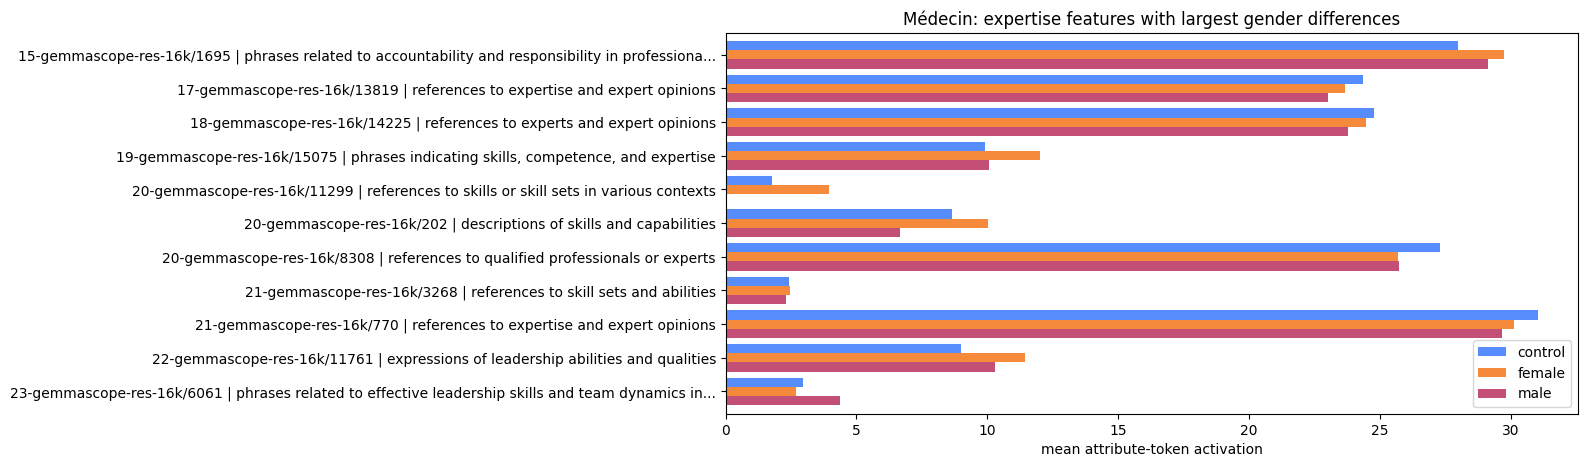

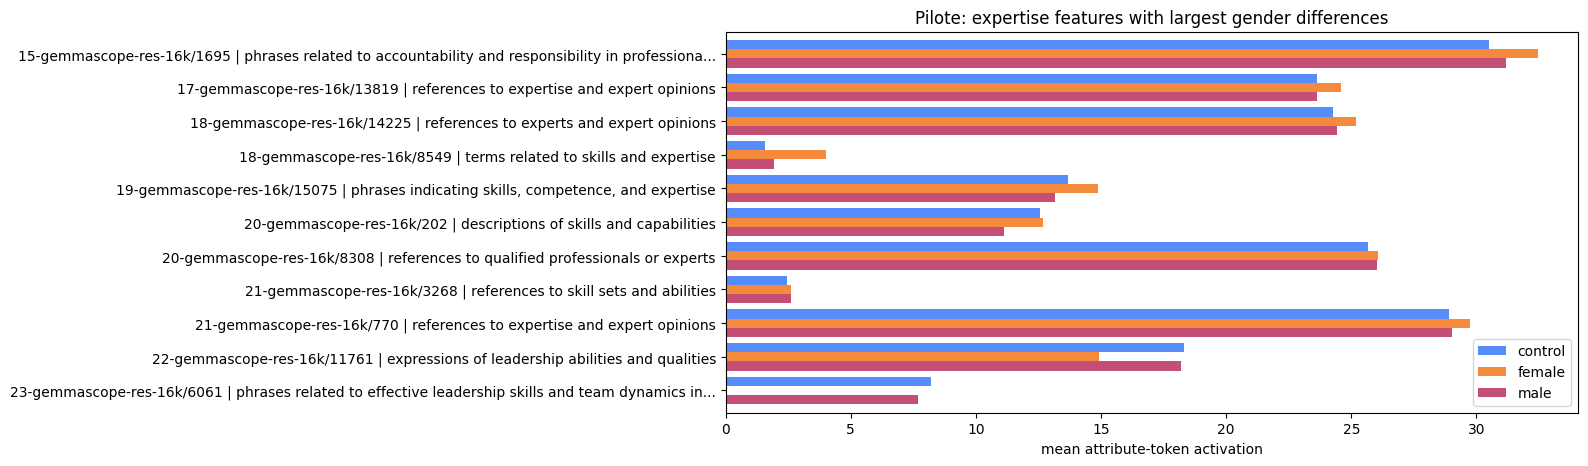

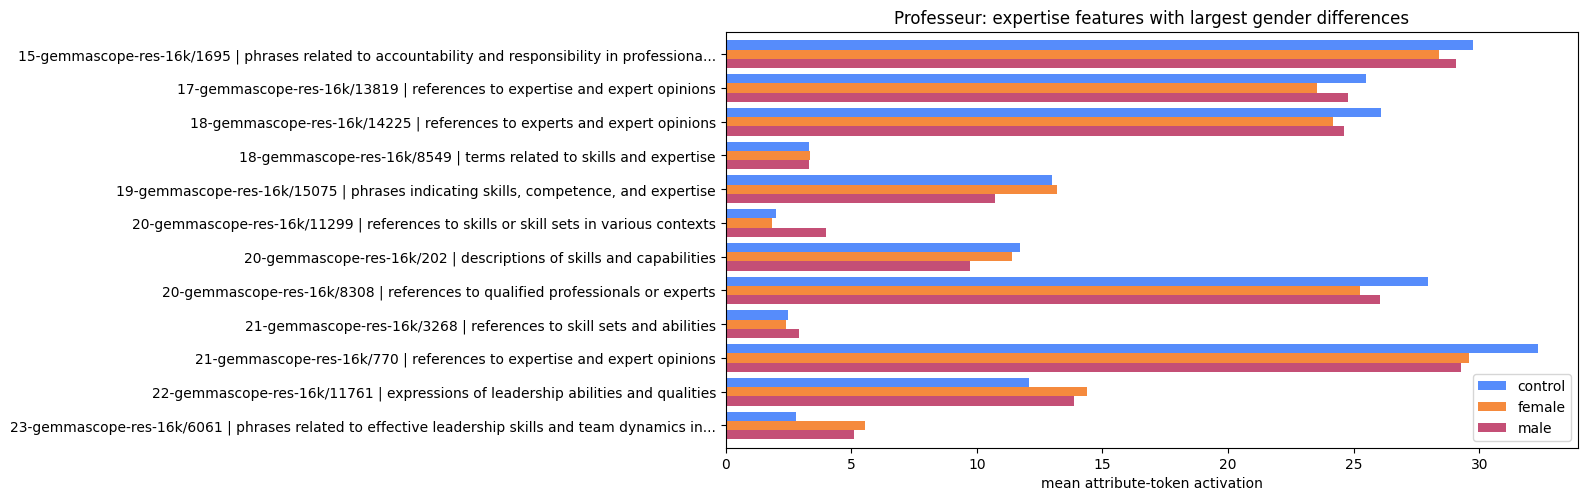

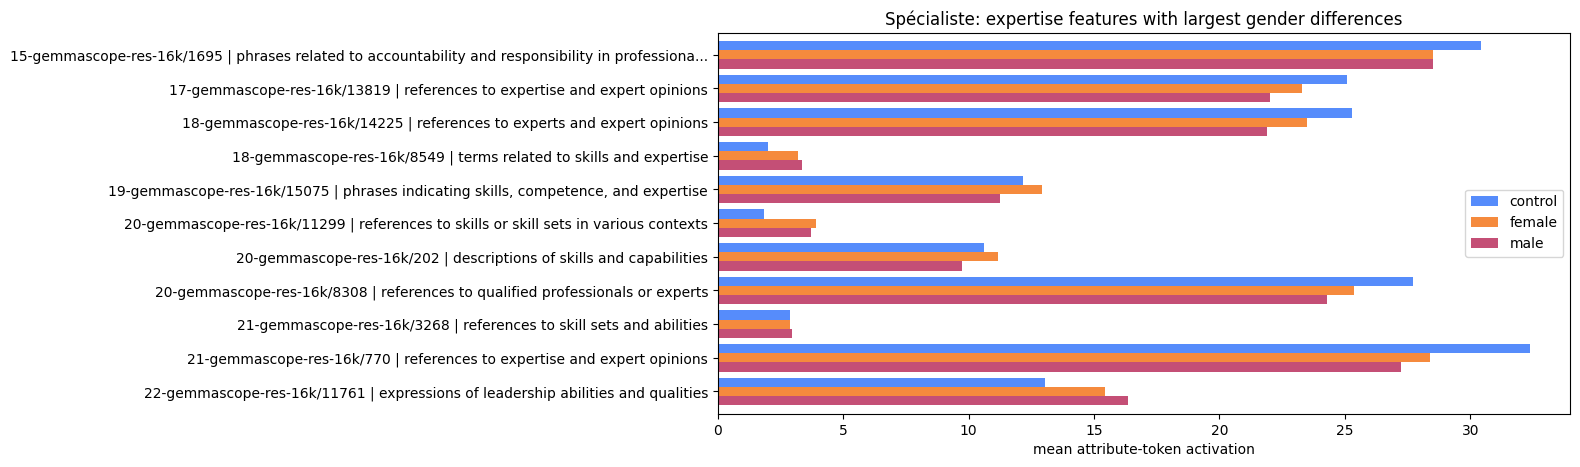

In [30]:
TOP_DIFFERENCE_FEATURES = 12


def short_label(row: pd.Series, max_description_chars: int = 70) -> str:
    description = str(row.get("description") or "").strip()
    if len(description) > max_description_chars:
        description = description[: max_description_chars - 3].rstrip() + "..."
    if description:
        return f"{row['feature']} | {description}"
    return str(row["feature"])


for profession, table in contrast_tables.items():
    top_difference_features = table[table['control'] > 0].head(TOP_DIFFERENCE_FEATURES).copy()
    top_difference_features["label"] = top_difference_features.apply(short_label, axis=1)

    feature_difference_long = top_difference_features.melt(
        id_vars=[
            "feature",
            "label",
            "description",
            "expertise_prompt_count",
            "expertise_mean_activation",
            "male_minus_control",
            "female_minus_control",
            "male_minus_female",
            "spread",
        ],
        value_vars=[col for col in ["control", "male", "female"] if col in top_difference_features.columns],
        var_name="gender_group",
        value_name="mean_attribute_activation",
    )

    ax = feature_difference_long.pivot(
        index="label",
        columns="gender_group",
        values="mean_attribute_activation",
    ).plot.barh(
        figsize=(11, max(4, 0.45 * len(top_difference_features))),
        width=0.82,
        title=f"{profession.title()}: expertise features with largest gender differences",
    )
    ax.invert_yaxis()
    ax.set_xlabel("mean attribute-token activation")
    ax.set_ylabel("")
    ax.legend(title="")

    display(
        top_difference_features[
            [
                "feature",
                "description",
                "spread",
                "control",
                "male",
                "female",
                "male_minus_control",
                "female_minus_control",
                "male_minus_female",
                "expertise_prompt_count",
                "expertise_mean_activation",
            ]
        ]
    )

## 12. Gender Disparity Plots

These plots do not use group averages. For each feature, they compare matched male and female prompt pairs, keep only pairs where both activations are non-zero, then plot the single largest absolute male-female gap.

,feature,description,prompt_pair,male_minus_female,abs_male_female_gap,male,female,expertise_prompt_count,expertise_mean_activation
10,19-gemmascope-res-16k/15075,"phrases indicating skills, competence, and expertise",qualifié,-8.2500,8.2500,10.12500,18.37500,4,64.125
12,20-gemmascope-res-16k/202,descriptions of skills and capabilities,qualifié,-7.1250,7.1250,9.12500,16.25000,3,64.750
20,23-gemmascope-res-16k/6061,phrases related to effective leadership skills and team dynamics in a professional context,capable_expérimenté,6.7500,6.7500,17.50000,10.75000,2,48.875
18,22-gemmascope-res-16k/11761,expressions of leadership abilities and qualities,capable_expérimenté,5.2500,5.2500,26.25000,21.00000,2,47.625
0,15-gemmascope-res-16k/1695,phrases related to accountability and responsibility in professional or organizational contexts,capable_expérimenté,-2.2500,2.2500,38.75000,41.00000,2,44.125
4,17-gemmascope-res-16k/13819,references to expertise and expert opinions,qualifié,-2.1250,2.1250,8.12500,10.25000,1,107.000
6,18-gemmascope-res-16k/14225,references to experts and expert opinions,qualifié,-1.7500,1.7500,12.62500,14.37500,1,105.500
14,20-gemmascope-res-16k/8308,references to qualified professionals or experts,qualifié,1.6250,1.6250,12.93750,11.31250,1,109.000
16,21-gemmascope-res-16k/770,references to expertise and expert opinions,expert_qualifié,-1.5000,1.5000,103.50000,105.00000,1,130.000
15,21-gemmascope-res-16k/3268,references to skill sets and abilities,qualifié,-0.6250,0.6250,9.25000,9.87500,1,96.500


,feature,description,prompt_pair,male_minus_female,abs_male_female_gap,male,female,expertise_prompt_count,expertise_mean_activation
31,19-gemmascope-res-16k/15075,"phrases indicating skills, competence, and expertise",qualifié,-9.50000,9.50000,10.12500,19.6250,4,64.125
41,22-gemmascope-res-16k/11761,expressions of leadership abilities and qualities,capable_expérimenté,9.25000,9.25000,33.00000,23.7500,2,47.625
35,20-gemmascope-res-16k/202,descriptions of skills and capabilities,qualifié,-8.93750,8.93750,8.31250,17.2500,3,64.750
21,15-gemmascope-res-16k/1695,phrases related to accountability and responsibility in professional or organizational contexts,capable_expérimenté,-3.75000,3.75000,38.75000,42.5000,2,44.125
39,21-gemmascope-res-16k/770,references to expertise and expert opinions,expert_qualifié,-3.00000,3.00000,101.00000,104.0000,1,130.000
25,17-gemmascope-res-16k/13819,references to expertise and expert opinions,qualifié,-2.87500,2.87500,10.50000,13.3750,1,107.000
36,20-gemmascope-res-16k/8308,references to qualified professionals or experts,expert_qualifié,-1.50000,1.50000,89.50000,91.0000,1,109.000
26,18-gemmascope-res-16k/14225,references to experts and expert opinions,expert_qualifié,-1.50000,1.50000,82.00000,83.5000,1,105.500
28,18-gemmascope-res-16k/8549,terms related to skills and expertise,expert_qualifié,-0.84375,0.84375,7.65625,8.5000,1,95.500
32,20-gemmascope-res-16k/11299,references to skills or skill sets in various contexts,qualifié,-0.75000,0.75000,7.93750,8.6875,1,98.500


,feature,description,prompt_pair,male_minus_female,abs_male_female_gap,male,female,expertise_prompt_count,expertise_mean_activation
55,19-gemmascope-res-16k/15075,"phrases indicating skills, competence, and expertise",expert_qualifié,-7.7500,7.7500,20.00000,27.75000,4,64.125
59,20-gemmascope-res-16k/202,descriptions of skills and capabilities,expert_qualifié,-5.8750,5.8750,16.37500,22.25000,3,64.750
47,15-gemmascope-res-16k/1695,phrases related to accountability and responsibility in professional or organizational contexts,qualifié,4.7500,4.7500,38.00000,33.25000,2,44.125
67,22-gemmascope-res-16k/11761,expressions of leadership abilities and qualities,expert_qualifié,-3.7500,3.7500,13.62500,17.37500,2,47.625
62,20-gemmascope-res-16k/8308,references to qualified professionals or experts,qualifié,3.6875,3.6875,16.75000,13.06250,1,109.000
64,21-gemmascope-res-16k/770,references to expertise and expert opinions,expert_qualifié,-3.5000,3.5000,98.00000,101.50000,1,130.000
48,17-gemmascope-res-16k/13819,references to expertise and expert opinions,expert_qualifié,2.5000,2.5000,84.50000,82.00000,1,107.000
63,21-gemmascope-res-16k/3268,references to skill sets and abilities,qualifié,2.1250,2.1250,11.75000,9.62500,1,96.500
69,23-gemmascope-res-16k/6061,phrases related to effective leadership skills and team dynamics in a professional context,capable_expérimenté,-1.6250,1.6250,20.50000,22.12500,2,48.875
57,20-gemmascope-res-16k/11299,references to skills or skill sets in various contexts,qualifié,1.3750,1.3750,8.68750,7.31250,1,98.500


,feature,description,prompt_pair,male_minus_female,abs_male_female_gap,male,female,expertise_prompt_count,expertise_mean_activation
81,19-gemmascope-res-16k/15075,"phrases indicating skills, competence, and expertise",qualifié,-4.500,4.500,11.25000,15.75000,4,64.125
73,17-gemmascope-res-16k/13819,references to expertise and expert opinions,expert_qualifié,-4.000,4.000,78.00000,82.00000,1,107.000
75,18-gemmascope-res-16k/14225,references to experts and expert opinions,expert_qualifié,-4.000,4.000,75.00000,79.00000,1,105.500
87,20-gemmascope-res-16k/8308,references to qualified professionals or experts,expert_qualifié,-3.500,3.500,84.00000,87.50000,1,109.000
86,20-gemmascope-res-16k/202,descriptions of skills and capabilities,qualifié,-3.375,3.375,10.75000,14.12500,3,64.750
95,23-gemmascope-res-16k/6061,phrases related to effective leadership skills and team dynamics in a professional context,capable_expérimenté,-3.250,3.250,31.25000,34.50000,2,48.875
90,21-gemmascope-res-16k/770,references to expertise and expert opinions,expert_qualifié,-3.000,3.000,94.00000,97.00000,1,130.000
93,22-gemmascope-res-16k/11761,expressions of leadership abilities and qualities,expert_qualifié,2.375,2.375,18.62500,16.25000,2,47.625
72,15-gemmascope-res-16k/1695,phrases related to accountability and responsibility in professional or organizational contexts,qualifié,1.750,1.750,36.50000,34.75000,2,44.125
83,20-gemmascope-res-16k/11299,references to skills or skill sets in various contexts,qualifié,-0.500,0.500,7.93750,8.43750,1,98.500


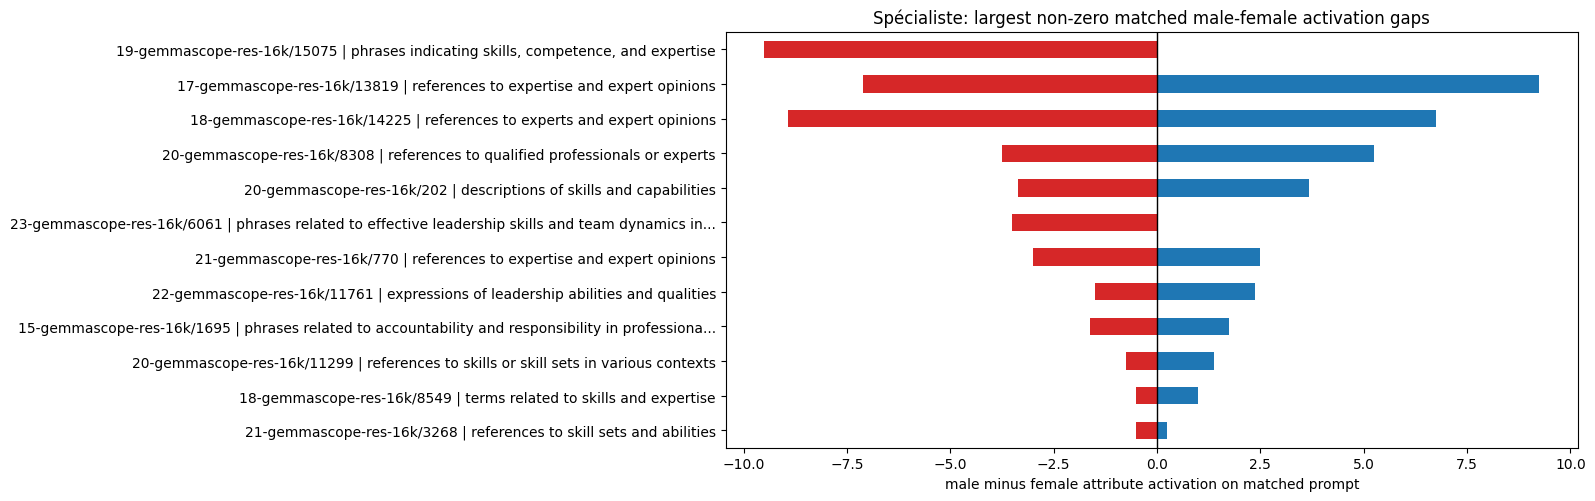

In [31]:
TOP_GENDER_DISPARITY_FEATURES = 12

pair_disparities = (
    activation_records[activation_records["gender_group"].isin(["male", "female"])]
    .pivot_table(
        index=[
            "profession",
            "feature",
            "source",
            "feature_index",
            "prompt_pair",
            "expertise_prompt_count",
            "expertise_mean_activation",
        ],
        columns="gender_group",
        values="attribute_activation",
        aggfunc="max",
        fill_value=0.0,
    )
    .reset_index()
)

pair_disparities = pair_disparities[
    (pair_disparities.get("male", 0.0) > 0)
    & (pair_disparities.get("female", 0.0) > 0)
].copy()

pair_disparities["male_minus_female"] = pair_disparities["male"] - pair_disparities["female"]
pair_disparities["abs_male_female_gap"] = pair_disparities["male_minus_female"].abs()
pair_disparities = pair_disparities.merge(
    feature_descriptions[["feature", "description"]],
    on="feature",
    how="left",
)

gender_disparity_tables = {}

for profession, frame in pair_disparities.groupby("profession"):
    idx = frame.groupby("feature")["abs_male_female_gap"].idxmax()
    disparity = (
        frame.loc[idx]
        .sort_values(["abs_male_female_gap", "expertise_prompt_count", "expertise_mean_activation"], ascending=[False, False, False])
        .head(TOP_GENDER_DISPARITY_FEATURES)
        .copy()
    )
    disparity["label"] = disparity.apply(short_label, axis=1)
    gender_disparity_tables[profession] = disparity

    colors = ["#1f77b4" if value >= 0 else "#d62728" for value in disparity["male_minus_female"]]
    ax = disparity.set_index("label")["male_minus_female"].plot.barh(
        figsize=(11, max(4, 0.45 * len(disparity))),
        color=colors,
        title=f"{profession.title()}: largest non-zero matched male-female activation gaps",
    )
    ax.axvline(0, color="black", linewidth=0.8)
    ax.invert_yaxis()
    ax.set_xlabel("male minus female attribute activation on matched prompt")
    ax.set_ylabel("")

    display(
        disparity[
            [
                "feature",
                "description",
                "prompt_pair",
                "male_minus_female",
                "abs_male_female_gap",
                "male",
                "female",
                "expertise_prompt_count",
                "expertise_mean_activation",
            ]
        ]
    )

## 13. Group Plot

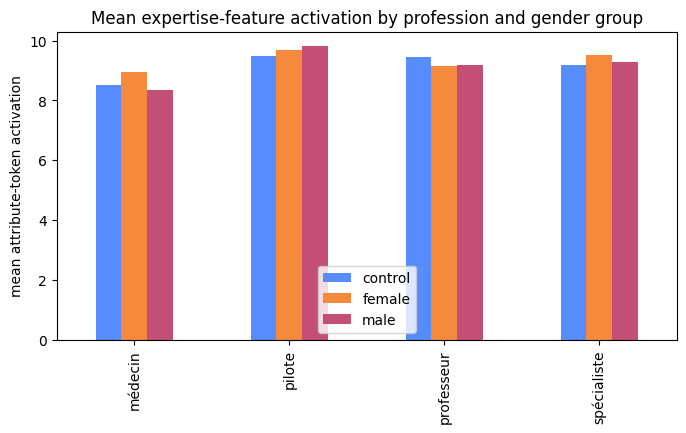

In [32]:
ax = group_summary.pivot(
    index="profession",
    columns="gender_group",
    values="mean_attribute_activation",
).plot.bar(
    figsize=(8, 4),
    title="Mean expertise-feature activation by profession and gender group",
)
ax.set_xlabel("")
ax.set_ylabel("mean attribute-token activation")
ax.legend(title="")

## 14. Interpretation

Use `group_summary` for overall averages, `contrast_tables` for per-profession feature tables, and `gender_disparity_tables` for the largest non-zero matched male-female activation gaps.